# DROID-100 Exploratory Data Analysis

Sanity-checks the data pipeline end-to-end before training.
Run top-to-bottom. Requires `GWM_PATH` env var set to repo root.

**Cells:**
1. Raw dataset stats from the on-disk JSON
2. Trajectory length distribution
3. Train/val split verification
4. Image sanity check (stereo pairs from `DroidDataset`)
5. Action & proprioception distributions + normalization check
6. Splatt3r output spot-check

In [ ]:
import tensorflow_datasets as tfds
import numpy as np
from PIL import Image
from IPython import display
import os

GWM_PATH = os.environ.get('GWM_PATH', os.path.expanduser('~/Workspace/gaussianwm'))
DROID100_DIR = os.path.join(GWM_PATH, 'data')

def as_gif(images, path="/tmp/droid_traj.gif"):
    """Render images as a GIF at 15Hz (DROID control frequency)."""
    images[0].save(path, save_all=True, append_images=images[1:], duration=int(1000/15), loop=0)
    return open(path, "rb").read()

ds = tfds.load("droid_100", data_dir=DROID100_DIR, split="train")

images = []
for episode in ds.shuffle(10, seed=0).take(1):
    for step in episode["steps"]:
        images.append(
            Image.fromarray(
                np.concatenate((
                    step["observation"]["exterior_image_1_left"].numpy(),
                    step["observation"]["exterior_image_2_left"].numpy(),
                    step["observation"]["wrist_image_left"].numpy(),
                ), axis=1)
            )
        )

display.Image(as_gif(images))

In [9]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt
import torch

# ---------------------------------------------------------------------------
# Paths — adjust GWM_PATH if needed
# ---------------------------------------------------------------------------
GWM_PATH = os.environ.get('GWM_PATH', os.path.expanduser('~/Workspace/gaussianwm'))
sys.path.insert(0, GWM_PATH)
sys.path.insert(0, os.path.join(GWM_PATH, 'gaussianwm'))

DROID100_DIR = os.path.join(GWM_PATH, 'data', 'droid_100', '1.0.0')
print(f'GWM_PATH       : {GWM_PATH}')
print(f'DROID100_DIR   : {DROID100_DIR}')
print(f'Files on disk  : {os.listdir(DROID100_DIR)}')

GWM_PATH       : /home/frankcholula/Workspace/gaussianwm
DROID100_DIR   : /home/frankcholula/Workspace/gaussianwm/data/droid_100/1.0.0
Files on disk  : ['r2d2_faceblur-train.tfrecord-00010-of-00031', 'r2d2_faceblur-train.tfrecord-00022-of-00031', 'r2d2_faceblur-train.tfrecord-00016-of-00031', 'r2d2_faceblur-train.tfrecord-00024-of-00031', 'r2d2_faceblur-train.tfrecord-00012-of-00031', 'r2d2_faceblur-train.tfrecord-00003-of-00031', 'r2d2_faceblur-train.tfrecord-00006-of-00031', 'r2d2_faceblur-train.tfrecord-00030-of-00031', 'r2d2_faceblur-train.tfrecord-00015-of-00031', 'r2d2_faceblur-train.tfrecord-00026-of-00031', 'r2d2_faceblur-train.tfrecord-00029-of-00031', 'dataset_statistics_a1db6f7c9761e0c1120da4648c2200f575f382544cdf98b0b8587752b44cacc0.json', 'r2d2_faceblur-train.tfrecord-00025-of-00031', 'dataset_info.json', 'features.json', 'r2d2_faceblur-train.tfrecord-00004-of-00031', 'r2d2_faceblur-train.tfrecord-00028-of-00031', 'dataset_statistics_bebf86395759cd5d525a9b3ec3a594398608de6

---
## 1. Raw dataset stats

In [10]:
# ---------------------------------------------------------------------------
# Load the two metadata files that ship with the tfrecords
# ---------------------------------------------------------------------------
with open(os.path.join(DROID100_DIR, 'dataset_info.json')) as f:
    dataset_info = json.load(f)

# There may be two stats files (generated at different times); load both
stats_files = [f for f in os.listdir(DROID100_DIR) if f.startswith('dataset_statistics')]
dataset_stats = {}
for sf in stats_files:
    with open(os.path.join(DROID100_DIR, sf)) as f:
        dataset_stats[sf] = json.load(f)

# --- Print summary ---
print('=== dataset_info.json ===')
print(f"  Dataset name : {dataset_info['name']}")
print(f"  Splits       : {[s['name'] for s in dataset_info['splits']]}")
shard_lengths = [int(x) for x in dataset_info['splits'][0]['shardLengths']]
print(f"  Num shards   : {len(shard_lengths)}")
print(f"  Trajs/shard  : {shard_lengths}")
print(f"  Total trajs  : {sum(shard_lengths)}  (sum of shard lengths)")
print(f"  Total bytes  : {int(dataset_info['splits'][0]['numBytes']) / 1e9:.2f} GB")

print()
for sf, stats in dataset_stats.items():
    print(f'=== {sf} ===')
    print(f"  num_trajectories : {stats['num_trajectories']}")
    print(f"  num_transitions  : {stats['num_transitions']}")
    print(f"  avg traj length  : {stats['num_transitions'] / stats['num_trajectories']:.1f} frames")
    print(f"  action dim       : {len(stats['action']['mean'])}")
    print(f"  proprio dim      : {len(stats['proprio']['mean'])}")

=== dataset_info.json ===
  Dataset name : r2d2_faceblur
  Splits       : ['train']
  Num shards   : 31
  Trajs/shard  : [2, 5, 4, 2, 3, 2, 1, 4, 3, 1, 1, 3, 4, 7, 2, 6, 3, 2, 5, 2, 2, 3, 5, 6, 2, 2, 4, 5, 3, 2, 4]
  Total trajs  : 100  (sum of shard lengths)
  Total bytes  : 2.19 GB

=== dataset_statistics_a1db6f7c9761e0c1120da4648c2200f575f382544cdf98b0b8587752b44cacc0.json ===
  num_trajectories : 100
  num_transitions  : 32212
  avg traj length  : 322.1 frames
  action dim       : 10
  proprio dim      : 7
=== dataset_statistics_bebf86395759cd5d525a9b3ec3a594398608de654e1e7702e813394ac407f43a.json ===
  num_trajectories : 100
  num_transitions  : 32212
  avg traj length  : 322.1 frames
  action dim       : 10
  proprio dim      : 7


---
## 2. Trajectory length distribution

Iterates the raw tfrecords to get per-trajectory lengths.
Checks whether `segment_length=10` and `subsample_length=100` are compatible.

Trajectories loaded: 100
Min length : 13
Max length : 1627
Mean length: 322.1
Median     : 226
Std        : 272.9

Trajectories shorter than segment_length=10: 0


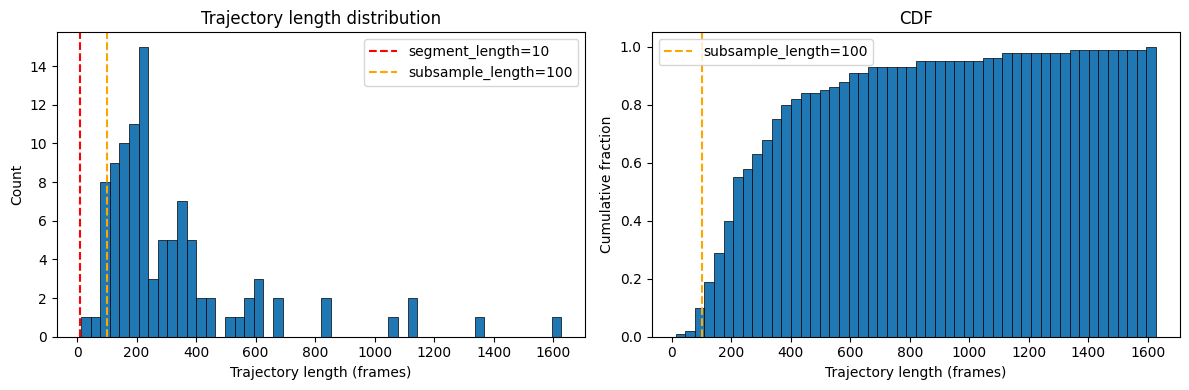

In [11]:
import tensorflow as tf
# Keep TF off GPU so it doesn't fight PyTorch
tf.config.set_visible_devices([], 'GPU')

import tensorflow_datasets as tfds

# ---------------------------------------------------------------------------
# Load raw trajectories (no transforms) and measure lengths
# ---------------------------------------------------------------------------
# tfds.builder expects data_dir to be the *parent* of the dataset folder.
# The on-disk layout is data/droid_100/1.0.0/*.tfrecord, so name="droid_100"
# and data_dir=data/.  (The internal dataset name "r2d2_faceblur" in
# dataset_info.json is irrelevant here; tfds uses the directory name.)
builder = tfds.builder('droid_100', data_dir=os.path.join(GWM_PATH, 'data'))
raw_ds = builder.as_dataset(split='train', shuffle_files=False)

traj_lengths = []
for i, traj in enumerate(raw_ds):
    # traj['steps'] is a tf.data.Dataset (one element per timestep), not a
    # plain tensor or dict — it is not subscriptable.  Use .cardinality() to
    # get the trajectory length directly; fall back to iteration if unknown.
    steps_ds = traj['steps']
    length = steps_ds.cardinality().numpy()
    if length < 0:  # UNKNOWN or INFINITE
        length = sum(1 for _ in steps_ds)
    traj_lengths.append(int(length))

traj_lengths = np.array(traj_lengths)
print(f'Trajectories loaded: {len(traj_lengths)}')
print(f'Min length : {traj_lengths.min()}')
print(f'Max length : {traj_lengths.max()}')
print(f'Mean length: {traj_lengths.mean():.1f}')
print(f'Median     : {np.median(traj_lengths):.0f}')
print(f'Std        : {traj_lengths.std():.1f}')
print()

# Flag short trajectories
SEGMENT_LENGTH = 10
short = traj_lengths < SEGMENT_LENGTH
print(f'Trajectories shorter than segment_length={SEGMENT_LENGTH}: {short.sum()}')

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(traj_lengths, bins=50, edgecolor='black', linewidth=0.5)
axes[0].axvline(SEGMENT_LENGTH, color='red', linestyle='--', label=f'segment_length={SEGMENT_LENGTH}')
axes[0].axvline(100, color='orange', linestyle='--', label='subsample_length=100')
axes[0].set_xlabel('Trajectory length (frames)')
axes[0].set_ylabel('Count')
axes[0].set_title('Trajectory length distribution')
axes[0].legend()

axes[1].hist(traj_lengths, bins=50, edgecolor='black', linewidth=0.5, cumulative=True, density=True)
axes[1].axvline(100, color='orange', linestyle='--', label='subsample_length=100')
axes[1].set_xlabel('Trajectory length (frames)')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('CDF')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Train / val split verification

**Known issues to check:**
- `dataset_info.json` only has a `train` split — no `val`. The RLDS pipeline therefore uses `train[:95%]` / `train[95%:]`.
- BUT `load_all_data_for_training=True` (the default in `make_interleaved_dataset`) overrides the train split back to the full `train`. This means **train sees all data**.
- Val is capped by `.take(shuffle_buffer_size)` in `rlds/dataset.py:591`.
- `subsample_length=100` only applies to train (not val).

This cell instantiates both train and val `DroidDataset` objects and checks lengths.

In [12]:
from processor.datasets import build_gaussian_splatting_reconstruction_dataset
from omegaconf import OmegaConf

# Replicate the config from configs/dataset/droid.yaml + configs/train_vae_single_gpu.yaml
dataset_cfg = OmegaConf.create({
    'dataset_name': 'droid',
    'data_path': os.path.join(GWM_PATH, 'data') + '/',
    'segment_length': 10,
    'context_length': 2,
    'action_dim': 10,
    'image_size': 128,
    'augment': False,
    'val_ratio': 0.1,
    'seed': 0,
    'camera_keys': ['primary', 'secondary'],
    'action_keys': ['actions'],
    'future_action_window_size': 15,
    'subsample_length': 100,
    'shuffle_buffer_size': 1000,
    'traj_transform_threads': 48,
    'traj_read_threads': 48,
})

print('Building train dataset...')
ds_train = build_gaussian_splatting_reconstruction_dataset('train', cfg=dataset_cfg)
print(f'  train dataset_length (reported): {len(ds_train)}')
print(f'  train dataset_statistics: {ds_train.dataset_statistics}')

print()
print('Building val dataset...')
ds_val = build_gaussian_splatting_reconstruction_dataset('val', cfg=dataset_cfg)
print(f'  val dataset_length (reported): {len(ds_val)}')
print(f'  val dataset_statistics: {ds_val.dataset_statistics}')

print()
print('--- Interpretation ---')
print(f'  shuffle_buffer_size = {dataset_cfg.shuffle_buffer_size}')
print(f'  Val is capped at shuffle_buffer_size samples via .take() in rlds/dataset.py:591')
print(f'  Train uses load_all_data_for_training=True => full dataset, no 95/5 split')
print(f'  => Train and val overlap. Val is just a small shuffled window of the same data.')

Building train dataset...


2026-02-05 12:08:02.321808: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization


Loading existing dataset statistics from /home/frankcholula/Workspace/gaussianwm/data/droid_100/1.0.0/dataset_statistics_a1db6f7c9761e0c1120da4648c2200f575f382544cdf98b0b8587752b44cacc0.json.


2026-02-05 12:08:03.326318: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization



######################################################################################
# Loading the following 1 datasets (incl. sampling weight):                         #
# droid_100: ===============================================================1.000000 #
######################################################################################

Threads per Dataset: %s [48]
Reads per Dataset: %s [48]
Constructing datasets...


...

Applying frame transforms on dataset...
  train dataset_length (reported): 32212
  train dataset_statistics: {'droid_100': {'action': {'mean': array([ 5.27889729e-01,  5.51875308e-03,  3.10505629e-01,  7.04422414e-01,
       -7.95657746e-03,  9.04721394e-02,  5.66915201e-04, -7.12258399e-01,
       -1.57210417e-02,  4.05381978e-01]), 'std': array([0.11618718, 0.17677003, 0.15139177, 0.38304022, 0.5394873 ,
       0.24036923, 0.52912009, 0.38741612, 0.2497807 , 0.43608794]), 'max': array([0.84986585, 0.77035713, 0.79913259, 0.99999738, 0.99995524,
       0.99587429, 0.99991304, 0.98152697, 0.96426517, 1.        ]), 'min': array([ 0.14057738, -0.53113765, -0.13745312, -0.98765057, -0.99996555,
       -0.77054954, -0.99996388, -0.9999994 , -0.99731338,  0.        ]), 'q01': array([ 0.2874576 , -0.45600135, -0.02513219, -0.60186391, -0.99455819,
       -0.41586263, -0.98866985, -0.99927912, -0.83865511,  0.        ]), 'q99': array([0.79083982, 0.43174554, 0.68198124, 0.99886505, 0.994479  

2026-02-05 12:08:05.177783: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization
2026-02-05 12:08:05.339371: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization



######################################################################################
# Loading the following 1 datasets (incl. sampling weight):                         #
# droid_100: ===============================================================1.000000 #
######################################################################################

Threads per Dataset: %s [48]
Reads per Dataset: %s [48]
Constructing datasets...


2026-02-05 12:08:05.528358: I tensorflow/core/grappler/optimizers/data/replicate_on_split.cc:32] Running replicate on split optimization


Applying frame transforms on dataset...
  val dataset_length (reported): 32212
  val dataset_statistics: {'droid_100': {'action': {'mean': array([ 5.27889729e-01,  5.51875308e-03,  3.10505629e-01,  7.04422414e-01,
       -7.95657746e-03,  9.04721394e-02,  5.66915201e-04, -7.12258399e-01,
       -1.57210417e-02,  4.05381978e-01]), 'std': array([0.11618718, 0.17677003, 0.15139177, 0.38304022, 0.5394873 ,
       0.24036923, 0.52912009, 0.38741612, 0.2497807 , 0.43608794]), 'max': array([0.84986585, 0.77035713, 0.79913259, 0.99999738, 0.99995524,
       0.99587429, 0.99991304, 0.98152697, 0.96426517, 1.        ]), 'min': array([ 0.14057738, -0.53113765, -0.13745312, -0.98765057, -0.99996555,
       -0.77054954, -0.99996388, -0.9999994 , -0.99731338,  0.        ]), 'q01': array([ 0.2874576 , -0.45600135, -0.02513219, -0.60186391, -0.99455819,
       -0.41586263, -0.98866985, -0.99927912, -0.83865511,  0.        ]), 'q99': array([0.79083982, 0.43174554, 0.68198124, 0.99886505, 0.994479  ,
  

---
## 4. Image sanity check

Pull samples through the full `DroidDataset` iterator and visualize.
Checks: correct shape, not all black, float→uint8 conversion, stereo pair alignment.

/home/frankcholula/Workspace/gaussianwm/gaussianwm/processor/datasets.py:252: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  left_frames = torch.from_numpy(left_frames)


Collected 4 samples
  obs   shape/dtype : torch.Size([10, 128, 128, 3])  torch.uint8
  action shape/dtype: torch.Size([24, 10])  torch.float32
  reward shape      : torch.Size([10, 1])
  obs   range       : [0, 255]
  action range      : [-0.8393, 1.0000]


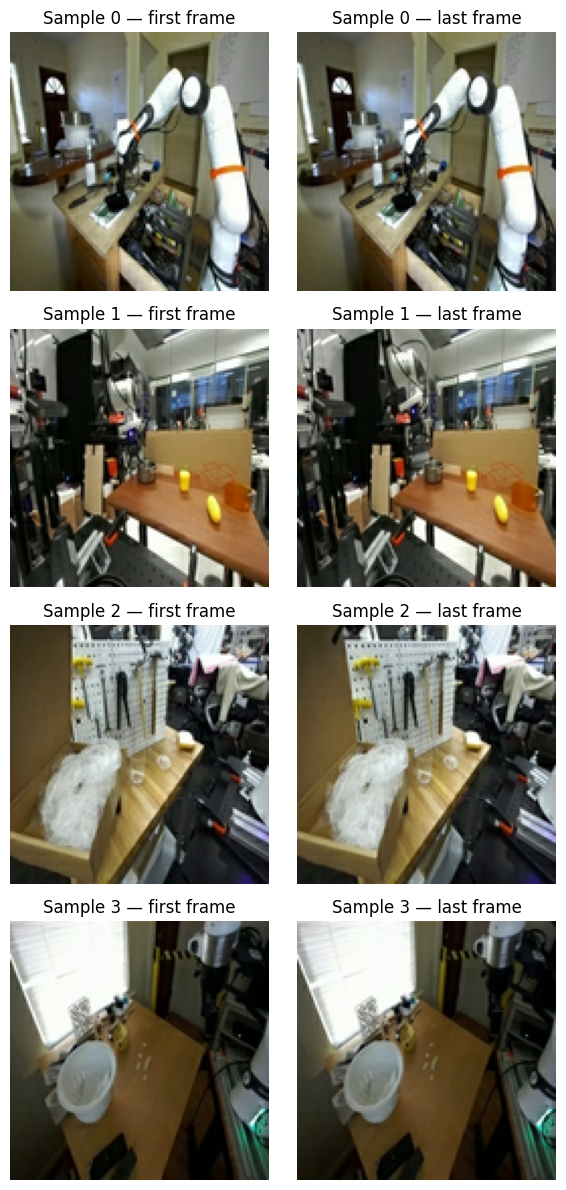

In [13]:
# ---------------------------------------------------------------------------
# Collect a few samples from the train iterator
# ---------------------------------------------------------------------------
N_SAMPLES = 4
samples = []
for i, (obs, action, reward) in enumerate(ds_train):
    samples.append((obs, action, reward))
    if i + 1 >= N_SAMPLES:
        break

print(f'Collected {len(samples)} samples')
obs0, act0, rew0 = samples[0]
print(f'  obs   shape/dtype : {obs0.shape}  {obs0.dtype}')  # expect [T, H, W, C]
print(f'  action shape/dtype: {act0.shape}  {act0.dtype}')
print(f'  reward shape      : {rew0.shape}')
print(f'  obs   range       : [{obs0.min().item()}, {obs0.max().item()}]')
print(f'  action range      : [{act0.min().item():.4f}, {act0.max().item():.4f}]')

# ---------------------------------------------------------------------------
# Visualize: one row per sample, show first and last frame in the segment
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(N_SAMPLES, 2, figsize=(6, 3 * N_SAMPLES))
for idx, (obs, _, _) in enumerate(samples):
    # obs is [T, H, W, C] uint8
    img_first = obs[0].numpy() if obs.dtype == torch.uint8 else (obs[0].numpy() * 255).astype(np.uint8)
    img_last  = obs[-1].numpy() if obs.dtype == torch.uint8 else (obs[-1].numpy() * 255).astype(np.uint8)
    # Handle CHW vs HWC
    if img_first.shape[0] in (1, 3):
        img_first = np.transpose(img_first, (1, 2, 0))
        img_last  = np.transpose(img_last, (1, 2, 0))
    axes[idx, 0].imshow(img_first)
    axes[idx, 0].set_title(f'Sample {idx} — first frame')
    axes[idx, 0].axis('off')
    axes[idx, 1].imshow(img_last)
    axes[idx, 1].set_title(f'Sample {idx} — last frame')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

---
## 5. Action & proprioception distributions + normalization check

- Plots histograms for each action dimension.
- Checks that dim 9 (gripper) is NOT normalized (should be raw 0/1), while dims 0–8 are bounded-normalized.
- Config: `action_normalization_mask = [True]*9 + [False]`, normalization type = `bounds`.

Action samples collected: 4800 timesteps, 10 dims


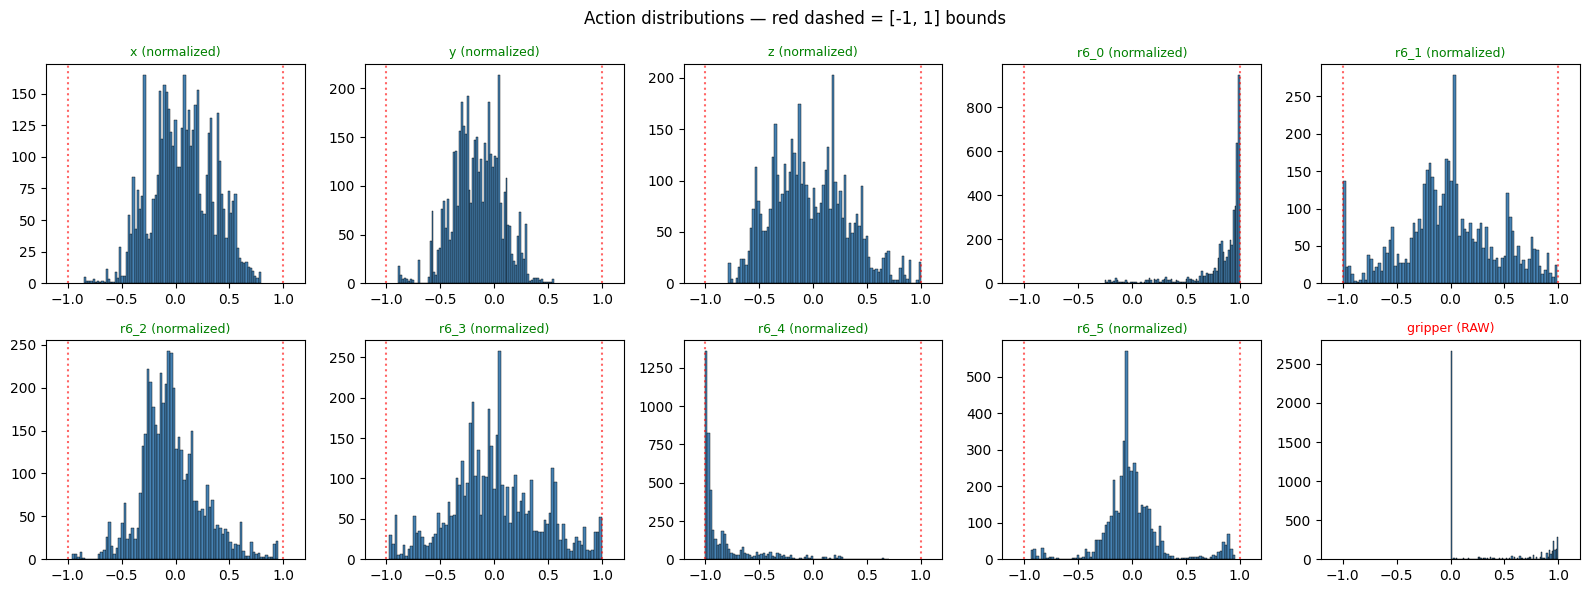


--- Normalization sanity check ---
  dim  0 (       x) : [-0.8516, +0.7910]  bounded [-1,1]: True
  dim  1 (       y) : [-0.8887, +0.5551]  bounded [-1,1]: True
  dim  2 (       z) : [-0.7846, +1.0000]  bounded [-1,1]: True
  dim  3 (    r6_0) : [-0.2510, +0.9999]  bounded [-1,1]: True
  dim  4 (    r6_1) : [-0.9957, +0.9893]  bounded [-1,1]: True
  dim  5 (    r6_2) : [-0.9590, +0.9524]  bounded [-1,1]: True
  dim  6 (    r6_3) : [-0.9742, +0.9988]  bounded [-1,1]: True
  dim  7 (    r6_4) : [-0.9999, +0.7017]  bounded [-1,1]: True
  dim  8 (    r6_5) : [-0.9353, +0.9574]  bounded [-1,1]: True
  dim  9 ( gripper) : [+0.0000, +1.0000]  binary {0,1}: False  unique: [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.25 0.26 0.27 0.28 0.29
 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42 0.43
 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55 0.56 0.57
 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0

In [14]:
# ---------------------------------------------------------------------------
# Collect action vectors from more samples for meaningful histograms
# ---------------------------------------------------------------------------
N_ACTION_SAMPLES = 200
all_actions = []
for i, (obs, action, reward) in enumerate(ds_train):
    # action shape: [T, action_dim] — flatten time dim
    all_actions.append(action.numpy())
    if i + 1 >= N_ACTION_SAMPLES:
        break

all_actions = np.concatenate(all_actions, axis=0)  # [N*T, 10]
print(f'Action samples collected: {all_actions.shape[0]} timesteps, {all_actions.shape[1]} dims')

# ---------------------------------------------------------------------------
# Plot per-dimension distributions
# ---------------------------------------------------------------------------
ACTION_DIM = all_actions.shape[1]
ACTION_LABELS = [
    'x', 'y', 'z',                          # translation (3)
    'r6_0', 'r6_1', 'r6_2',                 # rotation 6D first row (3)
    'r6_3', 'r6_4', 'r6_5',                 # rotation 6D second row (3)
    'gripper',                               # gripper (1, NOT normalized)
]

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
for d in range(ACTION_DIM):
    axes[d].hist(all_actions[:, d], bins=80, edgecolor='black', linewidth=0.3, color='steelblue')
    axes[d].set_title(ACTION_LABELS[d], fontsize=10)
    axes[d].set_xlim(-1.2, 1.2)
    # Mark expected range for normalized dims
    if d < 9:
        axes[d].axvline(-1, color='red', linestyle=':', alpha=0.6)
        axes[d].axvline(1,  color='red', linestyle=':', alpha=0.6)
        axes[d].set_title(f'{ACTION_LABELS[d]} (normalized)', fontsize=9, color='green')
    else:
        axes[d].set_title(f'{ACTION_LABELS[d]} (RAW)', fontsize=9, color='red')

plt.suptitle('Action distributions — red dashed = [-1, 1] bounds', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Explicit normalization check
# ---------------------------------------------------------------------------
print('\n--- Normalization sanity check ---')
for d in range(ACTION_DIM):
    mn, mx = all_actions[:, d].min(), all_actions[:, d].max()
    label = ACTION_LABELS[d]
    if d < 9:
        in_bounds = (-1.0 <= mn) and (mx <= 1.0)
        print(f'  dim {d:2d} ({label:>8s}) : [{mn:+.4f}, {mx:+.4f}]  bounded [-1,1]: {in_bounds}')
    else:
        is_binary = set(np.unique(np.round(all_actions[:, d], 2))).issubset({0.0, 1.0})
        print(f'  dim {d:2d} ({label:>8s}) : [{mn:+.4f}, {mx:+.4f}]  binary {{0,1}}: {is_binary}  unique: {np.unique(np.round(all_actions[:, d], 2))}')

---
## 6. Splatt3r output spot-check

Runs Splatt3r on a few images from the dataset and visualizes the output point clouds.
Checks: correct dimensionality (14D), no NaNs, XYZ looks like plausible 3D geometry.

> This cell loads the Splatt3r model (~1.5 GB checkpoint). Takes ~30s on first run.

In [15]:
# ---------------------------------------------------------------------------
# Load Splatt3r and run on sample images
# ---------------------------------------------------------------------------
from processor.regressor import Splatt3rRegressor
from pytorch3d.ops import sample_farthest_points as fps
import einops

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

print('Loading Splatt3r...')
splatt3r = Splatt3rRegressor().to(device)
splatt3r.eval()
print('Splatt3r loaded.')

# ---------------------------------------------------------------------------
# Prep images: use the samples we already collected
# obs is [T, H, W, C] uint8  ->  need [B, C, H, W] float
# ---------------------------------------------------------------------------
N_SPLAT = 4  # number of images to run through Splatt3r
images = []
for obs, _, _ in samples[:N_SPLAT]:
    # Take first frame of each segment
    frame = obs[0]  # [H, W, C] uint8
    frame = frame.float() / 255.0  # [H, W, C] float32
    frame = frame.permute(2, 0, 1)  # [C, H, W]
    images.append(frame)

image_batch = torch.stack(images).to(device)  # [B, C, H, W]
print(f'Image batch shape: {image_batch.shape}  range: [{image_batch.min():.3f}, {image_batch.max():.3f}]')

# ---------------------------------------------------------------------------
# Forward pass
# ---------------------------------------------------------------------------
with torch.no_grad():
    points, _ = splatt3r.forward_tensor(image_batch)

print(f'Raw Splatt3r output shape: {points.shape}')  # [B, N_raw, D]
print(f'  NaN count: {torch.isnan(points).sum().item()}')
print(f'  Inf count: {torch.isinf(points).sum().item()}')
print(f'  D (feature dim): {points.shape[-1]}  (expect 14 or 17 depending on pred keys)')

# Replicate the color normalization from train_vae.py
SH_C0 = 0.28209479177387814
colors = 0.5 + SH_C0 * points[..., -4:-1]
points[..., -4:-1] = colors / 255.0

# FPS downsample to 2048 (matching train config)
POINT_CLOUD_SIZE = 2048
points_fps, _ = fps(points, K=POINT_CLOUD_SIZE)
print(f'After FPS: {points_fps.shape}')

# ---------------------------------------------------------------------------
# Stats per dimension
# ---------------------------------------------------------------------------
print('\n--- Per-dimension stats (after color norm + FPS) ---')
dim_labels_14 = ['x','y','z', 's0','s1','s2', 'q0','q1','q2','q3', 'sh_r','sh_g','sh_b', 'opacity']
dim_labels_17 = ['x','y','z', 'x2','y2','z2', 's0','s1','s2', 'q0','q1','q2','q3', 'sh_r','sh_g','sh_b', 'opacity']
labels = dim_labels_14 if points_fps.shape[-1] == 14 else dim_labels_17
for d in range(points_fps.shape[-1]):
    vals = points_fps[..., d]
    lbl = labels[d] if d < len(labels) else f'd{d}'
    print(f'  {lbl:>8s}: min={vals.min():+10.4f}  max={vals.max():+10.4f}  mean={vals.mean():+10.4f}  nan={torch.isnan(vals).sum().item()}')

/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Loading Splatt3r...


/home/frankcholula/Workspace/gaussianwm/gaussianwm/processor/regressor.py:164: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(pretrained_model_name_or

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [on]


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


/home/frankcholula/Workspace/gaussianwm/.venv/lib/python3.10/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(

🔥🔥🔥 Splatt3r Model loaded from /home/frankcholula/Workspace/gaussianwm/third_party/splatt3r/checkpoints/splatt3r_v1.0/epoch=19-step=1200.ckpt
Splatt3r loaded.
Image batch shape: torch.Size([4, 3, 128, 128])  range: [0.000, 1.000]
Raw Splatt3r output shape: torch.Size([4, 16384, 14])
  NaN count: 0
  Inf count: 0
  D (feature dim): 14  (expect 14 or 17 depending on pred keys)
After FPS: torch.Size([4, 2048, 14])

--- Per-dimension stats (after color norm + FPS) ---
         x: min=   -2.1860  max=   +2.3559  mean=   +0.0483  nan=0
         y: min=   -2.6075  max=   +0.6372  mean=   -0.5347  nan=0
         z: min=   +0.6554  max=   +9.6333  mean=   +3.8905  nan=0
        s0: min=   +0.0011  max=   +0.2235  mean=   +0.0513  nan=0
        s1: min=   +0.0010  max=   +0.0368  mean=   +0.0124  nan=0
        s2: min=   +0.0010  max=   +0.0256  mean=   +0.0094  nan=0
        q0: min=   +0.2453  max=   +0.6266  mean=   +0.5957  nan=0
        q1: min=   +0.2019  max=   +0.5657  mean=   +0.4183  n

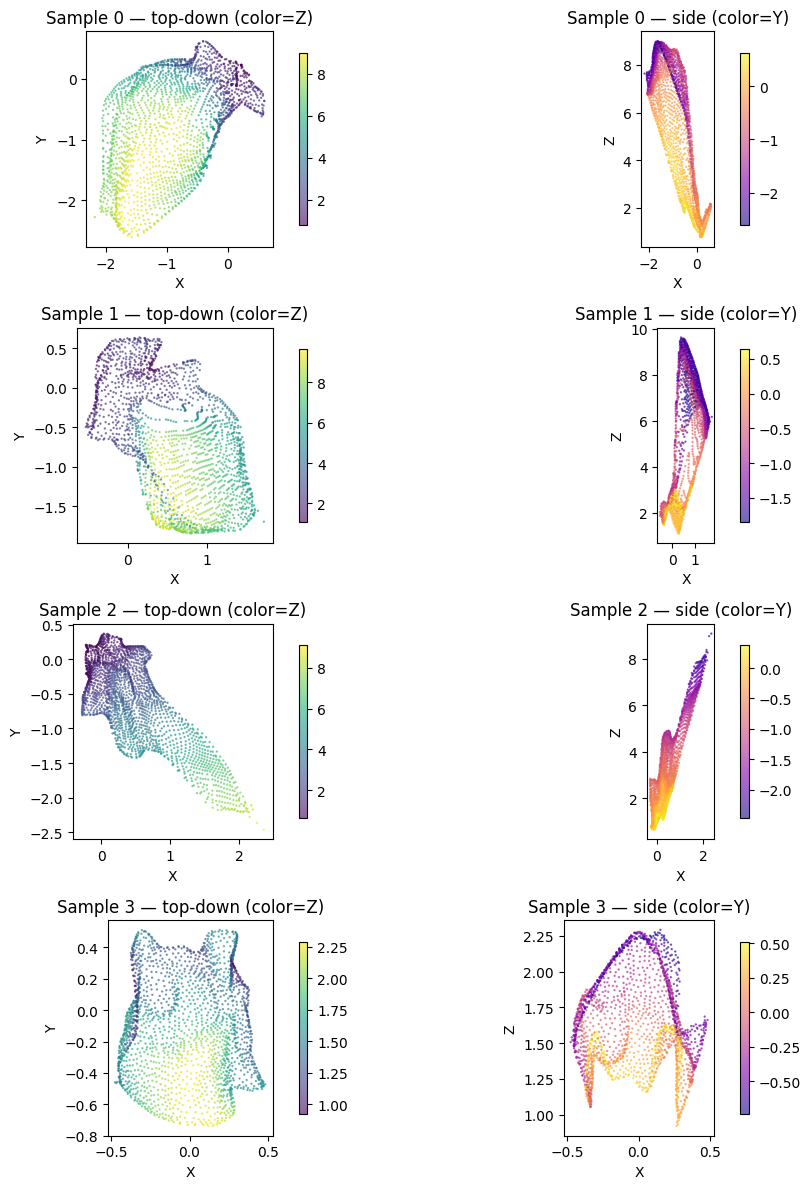

Done. Check the plots above for plausible 3D geometry.
If points are clustered at origin or form a flat plane, Splatt3r may not be working correctly.


In [16]:
# ---------------------------------------------------------------------------
# Visualize XYZ point clouds (top-down and side views)
# ---------------------------------------------------------------------------
pts_np = points_fps.cpu().numpy()  # [B, N, D]

fig, axes = plt.subplots(N_SPLAT, 2, figsize=(10, 3 * N_SPLAT))
for idx in range(N_SPLAT):
    xyz = pts_np[idx, :, :3]  # [N, 3]

    # --- Top-down: X vs Y ---
    sc0 = axes[idx, 0].scatter(xyz[:, 0], xyz[:, 1], c=xyz[:, 2],
                                cmap='viridis', s=0.5, alpha=0.6)
    axes[idx, 0].set_xlabel('X')
    axes[idx, 0].set_ylabel('Y')
    axes[idx, 0].set_title(f'Sample {idx} — top-down (color=Z)')
    axes[idx, 0].set_aspect('equal')
    plt.colorbar(sc0, ax=axes[idx, 0], shrink=0.8)

    # --- Side: X vs Z ---
    sc1 = axes[idx, 1].scatter(xyz[:, 0], xyz[:, 2], c=xyz[:, 1],
                                cmap='plasma', s=0.5, alpha=0.6)
    axes[idx, 1].set_xlabel('X')
    axes[idx, 1].set_ylabel('Z')
    axes[idx, 1].set_title(f'Sample {idx} — side (color=Y)')
    axes[idx, 1].set_aspect('equal')
    plt.colorbar(sc1, ax=axes[idx, 1], shrink=0.8)

plt.tight_layout()
plt.show()

print('Done. Check the plots above for plausible 3D geometry.')
print('If points are clustered at origin or form a flat plane, Splatt3r may not be working correctly.')